### Timing revisited

<font size = "4">

- I made a mistake way back in Lecture 4, when I discussed timing operations on mutable data structures, such as popping from a list.

- When using `heapify` to develop an $\mathcal{O}(n\log n)$ sorting algorithm in Assignment #4, you may want to remove elements from the original list and add them to a separate (ultimately sorted) list.

In [2]:
from timeit import timeit, Timer

In [3]:
# This will cause an error, because x.pop() changes x
x = list(range(200))
total_time = timeit(stmt = "x.pop()", number = 1000, 
    globals = {"x" : x})
print(f"x.pop(), the average time was {1000*total_time/num_repeats} milliseconds")

IndexError: pop from empty list

<font size = "4">

I said that using the `Timer` class could be used to deal with mutable data structures and showed the following code:

In [4]:
pop_zero = Timer("x.pop(0)", "from __main__ import x")
pop_end = Timer("x.pop()", "from __main__ import x")

x = list(range(2_000_000))
time1 = pop_zero.timeit(number=1000)
time2 = pop_end.timeit(number=1000)


print(f"pop(0): {time1:10.8f} milliseconds")
print(f"pop(): {time2:11.8f} milliseconds")

pop(0): 1.18865558 milliseconds
pop():  0.00005485 milliseconds


<font size = "4">

But the variable `x` has indeed changed, and we could run into the same issue:

In [5]:
# size of x is no longer 2 million
print(len(x))

1998000


In [7]:
pop_zero = Timer("x.pop(0)", "from __main__ import x")
pop_end = Timer("x.pop()", "from __main__ import x")


# If we change x to only have 200 elements, then we get an error.
x = list(range(200))
time1 = pop_zero.timeit(number=1000)
time2 = pop_end.timeit(number=1000)


print(f"pop(0): {time1:10.8f} milliseconds")
print(f"pop(): {time2:11.8f} milliseconds")

IndexError: pop from empty list

<font size = "4">

One way to deal with this is to manually time operations using `default_timer`

In [8]:
from timeit import default_timer

pop_zero = 0 
pop_end = 0

num_repeats = 1000
lst_size = 200_000

for k in range(num_repeats):
    
    # time popping from the end
    x = list(range(lst_size))
    start_time = default_timer()
    x.pop()
    stop_time = default_timer()
    pop_time = stop_time - start_time

    # add to total time
    pop_end += pop_time 


    # time popping from the beginning
    x = list(range(lst_size))
    start_time = default_timer()
    x.pop(0)
    stop_time = default_timer()
    pop_time = stop_time - start_time

    # add to total time
    pop_zero += pop_time


# default_timer is measured in SECONDS

print(f"pop(0) Average: {pop_zero/num_repeats:10.10f} seconds")
print(f"pop()  Average: {pop_end/num_repeats:10.10f} seconds")

print()
print(f"pop(0) Average: {1e3 * pop_zero/num_repeats:10.8f} milliseconds")
print(f"pop()  Average: {1e3 * pop_end/num_repeats:10.8f} milliseconds")

pop(0) Average: 0.0000971768 seconds
pop()  Average: 0.0000020248 seconds

pop(0) Average: 0.09717681 milliseconds
pop()  Average: 0.00202482 milliseconds


### Estimating cost graphically

<font size = "4">

We can also use `matplotlib.pyplot` to estimate the running time of algorithms. It is generally best to use logarithmic scaling on both axes:

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/1224831640.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, n_values, label = "$\mathcal{O}(n)$")
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/1224831640.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, n_values*np.log(n_values), label = "$\mathcal{O}(n\log n)$")
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/1224831640.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, n_values**2, label = "$\mathcal{O}(n^2)$")
/var/folder

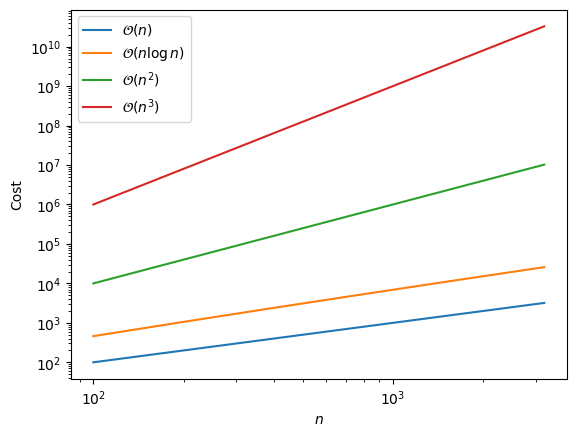

In [9]:
import matplotlib.pyplot as plt 
import numpy as np

n_values = np.array([100, 200, 400, 800, 1600, 3200])

plt.loglog(n_values, n_values, label = "$\mathcal{O}(n)$")
plt.loglog(n_values, n_values*np.log(n_values), label = "$\mathcal{O}(n\log n)$")
plt.loglog(n_values, n_values**2, label = "$\mathcal{O}(n^2)$")
plt.loglog(n_values, n_values**3, label = "$\mathcal{O}(n^3)$")
plt.xlabel("$n$")
plt.ylabel("Cost")

plt.legend()
plt.show()

<font size = "4">

- The slopes of the $\mathcal{O}(n^3)$ and $\mathcal{O}(n^2)$ curves clearly have a larger slope than the $\mathcal{O}(n)$ curve.

- But comparing $\mathcal{O}(n \log n)$ and $\mathcal{O}(n)$ is a little bit harder.

- Remember that constants are unimportant in big-Oh notation, so $\mathcal{O}(f(n)) = \mathcal{O}(C\cdot f(n))$ for any constant.

- It is often convenient to choose constants so that all curves have the same value for the smallest value of $n$.

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/4171731605.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, n_values, label = "$\mathcal{O}(n)$")
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/4171731605.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, C_2*n_values*np.log(n_values), label = "$\mathcal{O}(n\log n)$")
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/4171731605.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, C_3*n_values**2, label = "$\mathcal{O}(

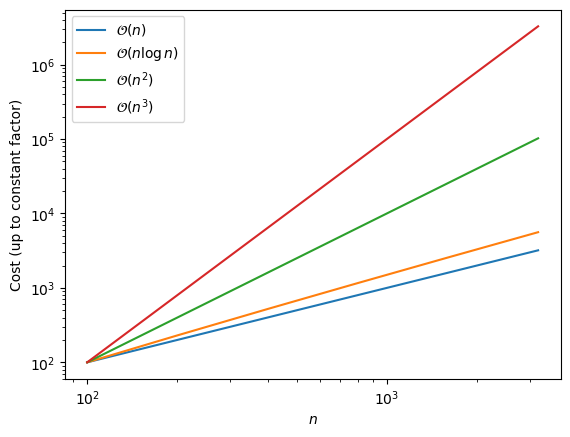

In [12]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

array_2 = n_values*np.log(n_values)
C_2 = n_values[0] / array_2[0]

array_3 = n_values**2
C_3 = n_values[0] / array_3[0]

array_4 = n_values**3
C_4 = n_values[0] / array_4[0]

plt.loglog(n_values, n_values, label = "$\mathcal{O}(n)$")
plt.loglog(n_values, C_2*n_values*np.log(n_values), label = "$\mathcal{O}(n\log n)$")
plt.loglog(n_values, C_3*n_values**2, label = "$\mathcal{O}(n^2)$")
plt.loglog(n_values, C_4*n_values**3, label = "$\mathcal{O}(n^3)$")
plt.xlabel("$n$")
plt.ylabel("Cost (up to constant factor)")

plt.legend()
plt.show()

<font size = "4">

In the code cell below, we have an array containing (hypothetical) run-times for 6 values of $n$.

We plot them against $C_1 n$ and $C_2 n\log n$, where the constants are chosen so that all 3 curves emanate from the same point.

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/1053185102.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, linear_cost, '.-', label = "$\mathcal{O}(n)$", markersize = 10)
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/1053185102.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, nlogn_cost, '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)


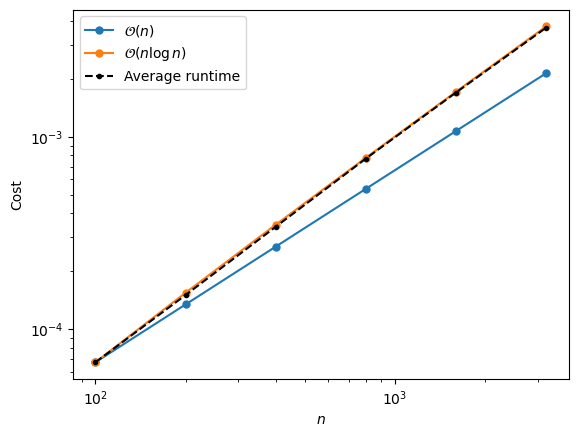

In [13]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3])

linear_cost = n_values 
C_1 = average_times[0] / linear_cost[0]
linear_cost = C_1 * linear_cost

nlogn_cost = n_values * np.log(n_values)
C_2 = average_times[0] / nlogn_cost[0]
nlogn_cost = C_2 * nlogn_cost


plt.loglog(n_values, linear_cost, '.-', label = "$\mathcal{O}(n)$", markersize = 10)
plt.loglog(n_values, nlogn_cost, '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)
plt.loglog(n_values, average_times, 'k.--', label = "Average runtime")
plt.xlabel("$n$")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [14]:
n_values.size

6

<font size = "4">

Note, however, that random fluctuations in the averages (and effects from lower order terms) might give an inconclusive plot if you start them at the same point.

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/3059360358.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, linear_cost, '.-', label = "$\mathcal{O}(n)$", markersize = 10)
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/3059360358.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, nlogn_cost, '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)


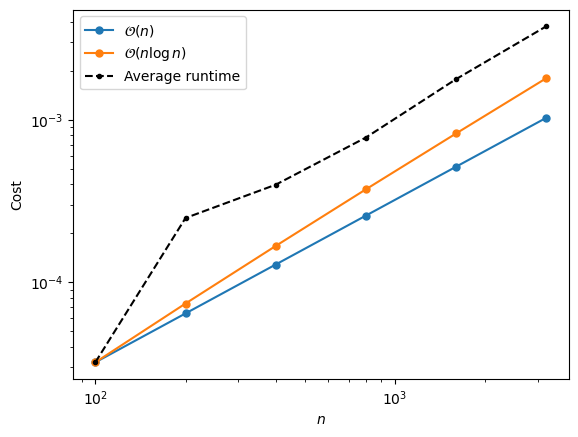

In [15]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

# add random noise to the average_times
np.random.seed(32)
average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3]) + \
    np.random.randn(n_values.size)*1e-4

linear_cost = n_values 
C_1 = average_times[0] / linear_cost[0]
linear_cost = C_1 * linear_cost

nlogn_cost = n_values * np.log(n_values)
C_2 = average_times[0] / nlogn_cost[0]
nlogn_cost = C_2 * nlogn_cost


plt.loglog(n_values, linear_cost, '.-', label = "$\mathcal{O}(n)$", markersize = 10)
plt.loglog(n_values, nlogn_cost, '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)
plt.loglog(n_values, average_times, 'k.--', label = "Average runtime")
plt.xlabel("$n$")
plt.ylabel("Cost")
plt.legend()
plt.show()

<font size = "4">

Since asymptotic notation deals with *large* values of $n$, it may make more sense to have them agree at the last point.

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/2850801832.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, linear_cost, '.-', label = "$\mathcal{O}(n)$", markersize = 10)
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/2850801832.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values, nlogn_cost, '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)


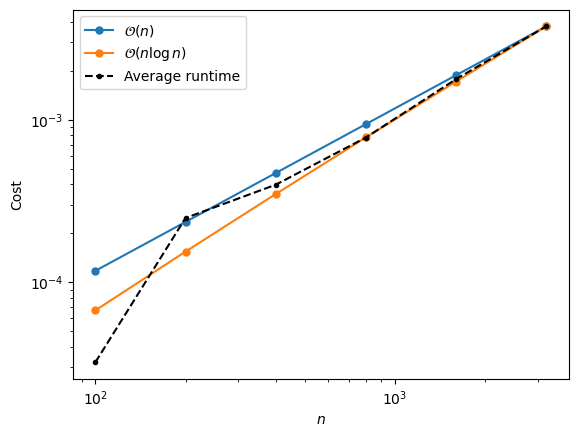

In [16]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

# add random noise to the average_times
np.random.seed(32)
average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3]) + \
    np.random.randn(n_values.size)*1e-4

idx = -1

linear_cost = n_values 
C_1 = average_times[idx] / linear_cost[idx]
linear_cost = C_1 * linear_cost

nlogn_cost = n_values * np.log(n_values)
C_2 = average_times[idx] / nlogn_cost[idx]
nlogn_cost = C_2 * nlogn_cost


plt.loglog(n_values, linear_cost, '.-', label = "$\mathcal{O}(n)$", markersize = 10)
plt.loglog(n_values, nlogn_cost, '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)
plt.loglog(n_values, average_times, 'k.--', label = "Average runtime")
plt.xlabel("$n$")
plt.ylabel("Cost")
plt.legend()
plt.show()

<font size = "4">

You might want to omit the smaller values of $n$ in your plot:

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/548884755.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values[plt_idx:], linear_cost[plt_idx:], '.-', label = "$\mathcal{O}(n)$", markersize = 10)
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/548884755.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values[plt_idx:], nlogn_cost[plt_idx:], '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)


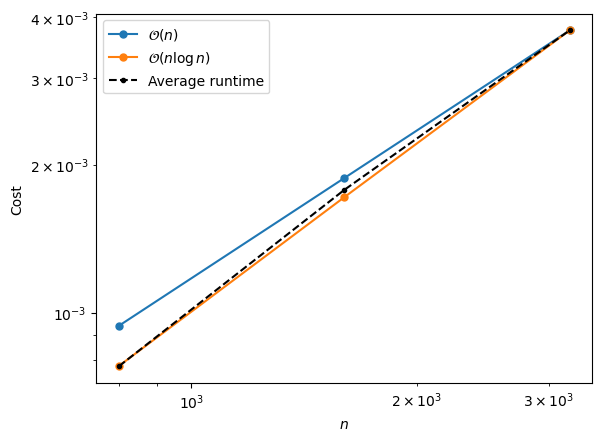

In [17]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

# add random noise to the average_times
np.random.seed(32)
average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3]) + \
    np.random.randn(n_values.size)*1e-4

idx = -1

linear_cost = n_values 
C_1 = average_times[idx] / linear_cost[idx]
linear_cost = C_1 * linear_cost

nlogn_cost = n_values * np.log(n_values)
C_2 = average_times[idx] / nlogn_cost[idx]
nlogn_cost = C_2 * nlogn_cost

plt_idx = 3

plt.loglog(n_values[plt_idx:], linear_cost[plt_idx:], '.-', label = "$\mathcal{O}(n)$", markersize = 10)
plt.loglog(n_values[plt_idx:], nlogn_cost[plt_idx:], '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)
plt.loglog(n_values[plt_idx:], average_times[plt_idx:], 'k.--', label = "Average runtime")
plt.xlabel("$n$")
plt.ylabel("Cost")
plt.legend()
plt.show()

<font size = "4">

Alternatively, you can keep the "big-Oh" plots separate and plot rescaled running times for each one.

Below, we choose the constants so they agree at the largest value of $n$

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/3649650011.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values[plt_idx:], linear_cost[plt_idx:], '.-', label = "$\mathcal{O}(n)$", markersize = 10)
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/3649650011.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values[plt_idx:], nlogn_cost[plt_idx:], '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)


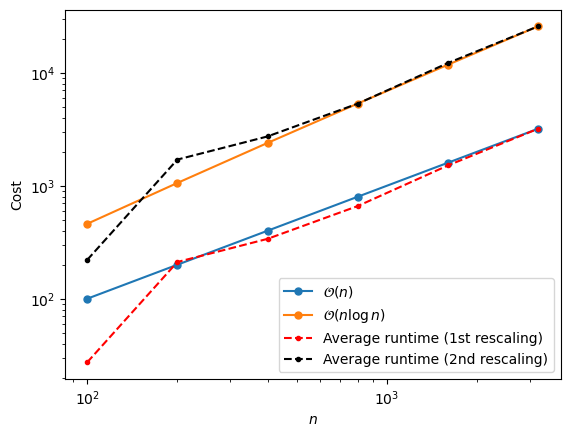

In [18]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

# add random noise to the average_times
np.random.seed(32)
average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3]) + \
    np.random.randn(n_values.size)*1e-4

idx = -1

linear_cost = n_values 
nlogn_cost = n_values * np.log(n_values)

C_1 = linear_cost[idx] / average_times[idx]

C_2 = nlogn_cost[idx] / average_times[idx]


plt_idx = 0

plt.loglog(n_values[plt_idx:], linear_cost[plt_idx:], '.-', label = "$\mathcal{O}(n)$", markersize = 10)
plt.loglog(n_values[plt_idx:], nlogn_cost[plt_idx:], '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)
plt.loglog(n_values[plt_idx:], C_1*average_times[plt_idx:], 'r.--', label = "Average runtime (1st rescaling)")
plt.loglog(n_values[plt_idx:], C_2*average_times[plt_idx:], 'k.--', label = "Average runtime (2nd rescaling)")
plt.xlabel("$n$")
plt.ylabel("Cost")
plt.legend()
plt.show()

<font size = "4">

You could also choose the constant based on the average ratio:

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/4262324396.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values[plt_idx:], linear_cost[plt_idx:], '.-', label = "$\mathcal{O}(n)$", markersize = 10)
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/4262324396.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values[plt_idx:], nlogn_cost[plt_idx:], '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)


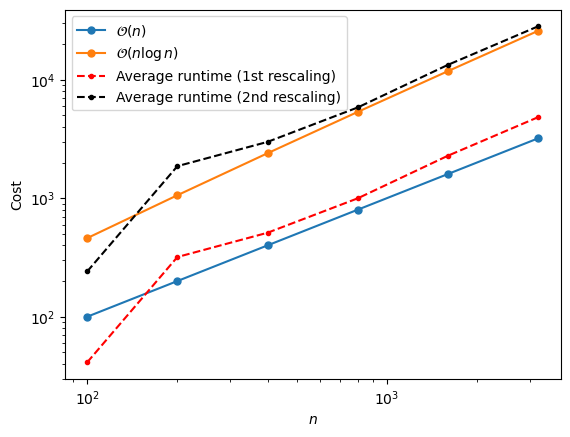

In [20]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

# add random noise to the average_times
np.random.seed(32)
average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3]) + \
    np.random.randn(n_values.size)*1e-4


linear_cost = n_values 
nlogn_cost = n_values * np.log(n_values)

# Compute using average
C_1 = np.mean(linear_cost / average_times)
C_2 = np.mean(nlogn_cost / average_times)



plt_idx = 0

plt.loglog(n_values[plt_idx:], linear_cost[plt_idx:], '.-', label = "$\mathcal{O}(n)$", markersize = 10)
plt.loglog(n_values[plt_idx:], nlogn_cost[plt_idx:], '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)
plt.loglog(n_values[plt_idx:], C_1*average_times[plt_idx:], 'r.--', label = "Average runtime (1st rescaling)")
plt.loglog(n_values[plt_idx:], C_2*average_times[plt_idx:], 'k.--', label = "Average runtime (2nd rescaling)")
plt.xlabel("$n$")
plt.ylabel("Cost")
plt.legend()
plt.show()

<font size = "4">

Or the median:

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/1430322031.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values[plt_idx:], linear_cost[plt_idx:], '.-', label = "$\mathcal{O}(n)$", markersize = 10)
/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_29318/1430322031.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.loglog(n_values[plt_idx:], nlogn_cost[plt_idx:], '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)


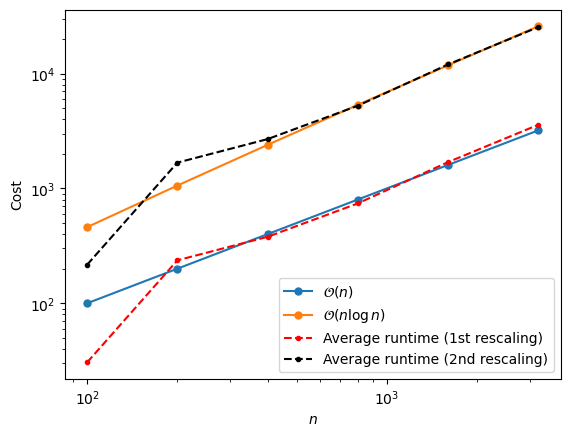

In [21]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

# add random noise to the average_times
np.random.seed(32)
average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3]) + \
    np.random.randn(n_values.size)*1e-4


linear_cost = n_values 
nlogn_cost = n_values * np.log(n_values)

# Compute using median
C_1 = np.median(linear_cost / average_times)
C_2 = np.median(nlogn_cost / average_times)



plt_idx = 0

plt.loglog(n_values[plt_idx:], linear_cost[plt_idx:], '.-', label = "$\mathcal{O}(n)$", markersize = 10)
plt.loglog(n_values[plt_idx:], nlogn_cost[plt_idx:], '.-', label = "$\mathcal{O}(n\log n)$", markersize = 10)
plt.loglog(n_values[plt_idx:], C_1*average_times[plt_idx:], 'r.--', label = "Average runtime (1st rescaling)")
plt.loglog(n_values[plt_idx:], C_2*average_times[plt_idx:], 'k.--', label = "Average runtime (2nd rescaling)")
plt.xlabel("$n$")
plt.ylabel("Cost")
plt.legend()
plt.show()

<font size = "4">

It's still pretty close. Would probably want to try one or more values of $n$, or compute the average using more repeats.

We could also plot the ratios of the average times to different functions of $n$. This would demonstrate that the cost is $\sim C\cdot n\log n$

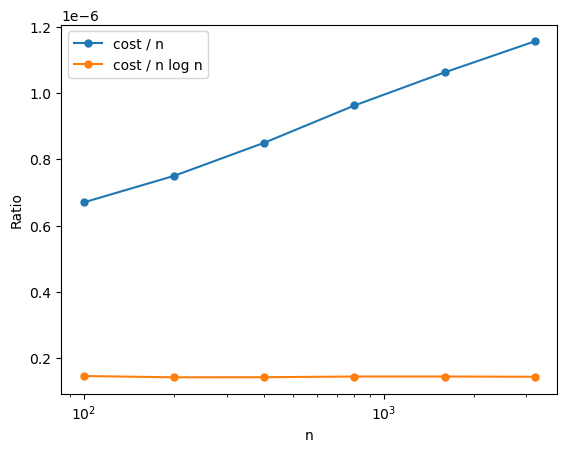

In [23]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3])


plt.semilogx(n_values, average_times/n_values,'.-', label = "cost / n",markersize = 10)
plt.semilogx(n_values, average_times/(n_values*np.log(n_values)),'.-', label = "cost / n log n",markersize = 10)
plt.xlabel("n")
plt.ylabel("Ratio")
plt.legend()
plt.show()

<font size = "4">



<font size = "4">

Here is the ratio plot when we add random noise.

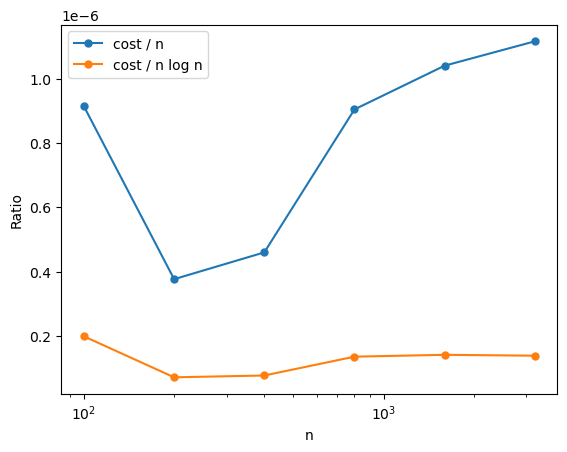

In [36]:
n_values = np.array([100, 200, 400, 800, 1600, 3200])

# add random noise to the average_times
np.random.seed(34)
average_times = np.array([6.7e-5, 1.5e-4, 3.4e-4, 7.7e-4, 1.7e-3, 3.7e-3]) + \
    np.random.randn(n_values.size)*1e-4


plt.semilogx(n_values, average_times/n_values,'.-', label = "cost / n",markersize = 10)
plt.semilogx(n_values, average_times/(n_values*np.log(n_values)),'.-', label = "cost / n log n",markersize = 10)
plt.xlabel("n")
plt.ylabel("Ratio")
plt.legend()
plt.show()